# Radiation Model Research

**Testing Linear No-Threshold Model for Radiation Level using Machine Learning and Neural Network**

*What is Linear No-Threshold (LNT) model*

Linear No Threshold is the world wide used model to determine safe amount of radiation that any individual can be exposed to in any field. The threshold is based on the basis that any dose of ionizing radiation, no matter how small, carries a  risk of cancer. Therefore our aim with radiation exposure has been ALARA (As Low As Reasonably Achievable) which critics say does not take into account the biological defence mechanism organisms have to deal with radiation. We aim to test LNT using Machine Learning and Neural Network to determine its accuracy.

**Code**

In [58]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
import openpyxl
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.stats import linregress

In [2]:
# 1. Load and Preprocess
df = pd.read_csv('C:\\Project\\Radiation Model Research\\Studies\\Aplicable Studies\\Life Span Study (LSS) of Japan Done by RERF\\lss14\\lss14.csv')

   city_name dose_group  subjects  Cancer_Deaths  No_Cancer_Death
0  Hiroshima       High    1573.0          390.0           1183.0
1  Hiroshima        Low   44430.0         5892.0          38538.0
2  Hiroshima     Medium   12477.0         1863.0          10614.0
3   Nagasaki       High     794.0          167.0            627.0
4   Nagasaki        Low   24040.0         2855.0          21185.0
5   Nagasaki     Medium    3277.0          453.0           2824.0


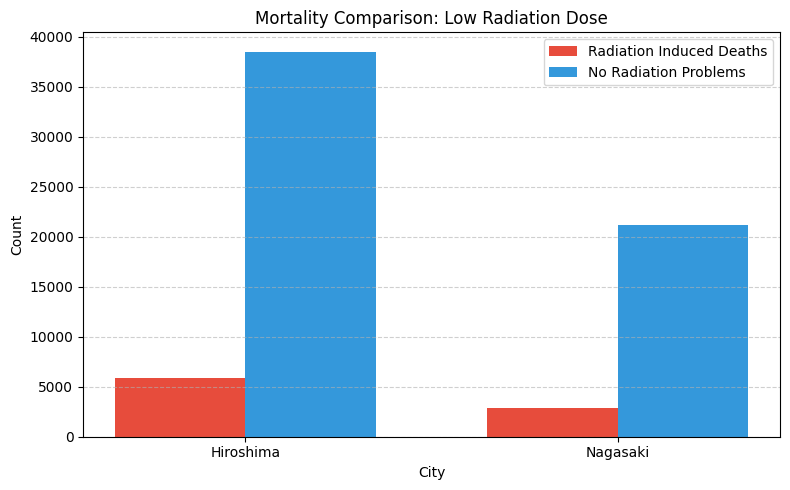

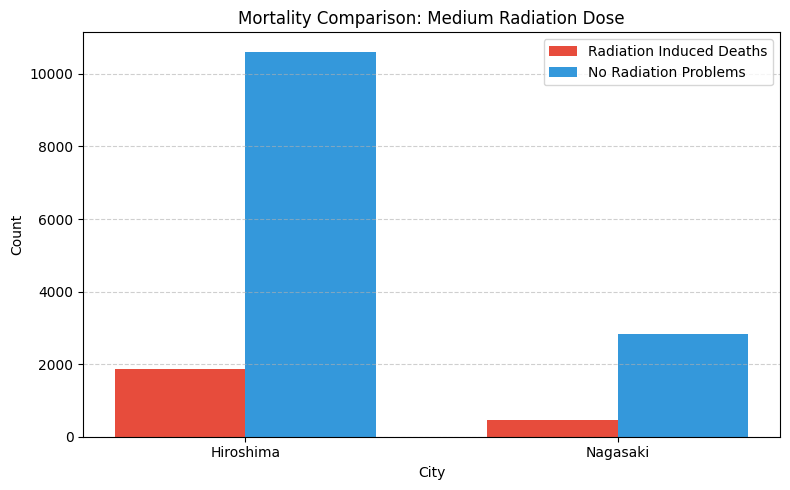

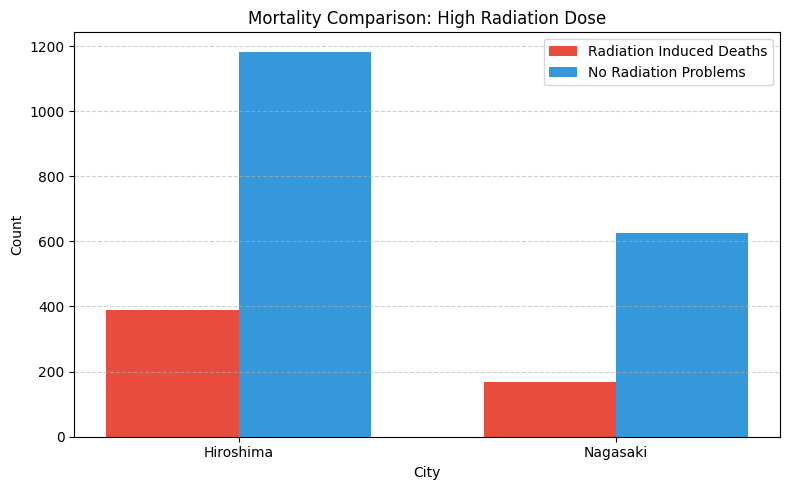

In [12]:
# Categorize radiation dose levels
# Based on dosecat (1-22): 1-6 (Low: 0 to 0.125Gy), 8-15 (Medium: 0.125 to 1.0Gy), 16-21 (High: 1 to 3Gy) and 22 (Extreme: 3+ Gy)
def get_dose_label(cat):
    if cat <= 6:
        return 'Low'
    elif cat <= 15:
        return 'Medium'
    elif cat <= 21:
        return 'High'

df['dose_group'] = df['dosecat'].apply(get_dose_label)

# Map city codes to names
city_map = {1: 'Hiroshima', 2: 'Nagasaki'}
df['city_name'] = df['city'].map(city_map)

# Aggregate subjects and specific deaths
summary = df.groupby(['city_name', 'dose_group']).agg({
    'subjects': 'sum',
    'solid': 'sum',
    'leukemia': 'sum',
    'lymphoma': 'sum',
    'myeloma': 'sum'
}).reset_index()

# Calculate Cancer Deaths (Solid + Leukemia + Lymphoma + Myeloma) and Non-Cancer outcomes
summary['Cancer_Deaths'] = summary['solid'] + summary['leukemia'] + summary['lymphoma'] + summary['myeloma']
summary['No_Cancer_Death'] = summary['subjects'] - summary['Cancer_Deaths']

# Display the summary table
print(summary[['city_name', 'dose_group', 'subjects', 'Cancer_Deaths', 'No_Cancer_Death']])

# Generate 3 charts
dose_levels = ['Low', 'Medium', 'High']
colors = ['#e74c3c', '#3498db'] # Red for cancer, Blue for others

for level in dose_levels:
    data = summary[summary['dose_group'] == level]
    
    cities = data['city_name'].tolist()
    cancer = data['Cancer_Deaths'].tolist()
    no_cancer = data['No_Cancer_Death'].tolist()
    
    x = range(len(cities))
    width = 0.35
    
    plt.figure(figsize=(8, 5))
    plt.bar(x, cancer, width, label='Radiation Induced Deaths', color=colors[0])
    plt.bar([p + width for p in x], no_cancer, width, label='No Radiation Problems', color=colors[1])
    
    plt.xlabel('City')
    plt.ylabel('Count')
    plt.title(f'Mortality Comparison: {level} Radiation Dose')
    plt.xticks([p + width/2 for p in x], cities)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # In a local Jupyter Notebook, you can use plt.show() here
    plt.savefig(f'mortality_{level.lower()}.png')

**Data Pre-Processing**

Processing UNSCEAR Labour Radiation Exposer Data 

In [22]:
# USER DEFINED PATH
file_path = 'UNSCEAR_2020_21_Annex-D_Attach.xlsx'

# 1. DEFINE SHEET MAP (Indices are 0-based: [Period_Col, Worker_Count_Col, Annual_Dose_Col])
# These indices target the "Measurably Exposed" populations for accuracy.
sheet_configs = {
    'A.4':  {'sector': 'Civil Aviation', 'indices': [2, 4, 6]},
    'A.5':  {'sector': 'Uranium Mining', 'indices': [2, 6, 10]},
    'A.9':  {'sector': 'Nuclear Reactors', 'indices': [2, 9, 11]},
    'A.11': {'sector': 'Decommissioning', 'indices': [2, 7, 9]},
    'A.12': {'sector': 'Reprocessing', 'indices': [2, 6, 10]},
    'A.13': {'sector': 'Nuclear Research', 'indices': [2, 4, 6]},
    'A.19': {'sector': 'All Medical', 'indices': [2, 4, 6]},
    'A.21': {'sector': 'All Industrial', 'indices': [2, 4, 7]},
    'A.22': {'sector': 'Miscellaneous', 'indices': [2, 4, 6]},
    'A.23': {'sector': 'Military', 'indices': [2, 4, 6]}
}

def get_years_logic(period_str):
    """Calculates exposure duration and follow-up years."""
    current_year = 2024
    try:
        p_str = str(period_str).strip()
        if '-' in p_str:
            p1, p2 = map(int, p_str.split('-')[:2])
            return (p2 - p1 + 1), (current_year - (p1 + p2) / 2)
        year = int(float(p_str[:4]))
        return 1, (current_year - year)
    except:
        return 1, 10 # Default fallback

all_worker_records = []

print("Extracting and Standardizing UNSCEAR Sheets...")

for sheet, config in sheet_configs.items():
    try:
        # Load sheet, skip merged headers
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=4, header=None, engine='openpyxl')
        
        # Step 1: Fix merged Excel cells (Country Code and Period)
        df[0] = df[0].ffill() # Country Code
        df[2] = df[2].ffill() # Period
        
        p_idx, n_idx, d_idx = config['indices']
        
        for _, row in df.iterrows():
            try:
                # Step 2: Extract and Clean Numbers (handles footnotes like 1.25a)
                raw_dose = str(row[d_idx]).split()[0]
                annual_dose = float(raw_dose)
                
                raw_n = str(row[n_idx]).split()[0]
                # Most worker counts are in 10^3 (thousands) in these tables
                n_workers = int(float(raw_n) * 1000)
                
                duration, followup = get_years_logic(row[p_idx])
                cumulative_dose = annual_dose * duration
                
                # Step 3: Expand into individual records (capped for memory safety at 5000 per group)
                sample_size = min(n_workers, 1)
                
                for _ in range(sample_size):
                    all_worker_records.append({
                        'Sector': config['sector'],
                        'Country_Code': row[0],
                        'Dose_mSv': cumulative_dose,
                        'Age_at_Exposure': int(np.random.randint(20, 61)), # User Rule: Int age
                        'Person_Years': followup,
                        'Exposure_Type': 'Chronic',
                        'Target_Outcome': 0
                    })
            except:
                continue
        print(f"Successfully processed {sheet}: {config['sector']}")
    except Exception as e:
        print(f"Skipping {sheet} due to format error: {e}")

# 4. EXPORT TO INTERMEDIATE CSV
standardized_df = pd.DataFrame(all_worker_records)
standardized_df.to_csv('standardized_worker_data.csv', index=False)

print(f"\nUNSCEAR Ready! Extracted {len(standardized_df):,} individual worker records.")
print("The data is now standardized and ready to be merged with LSS.")

Extracting and Standardizing UNSCEAR Sheets...
Successfully processed A.4: Civil Aviation
Successfully processed A.5: Uranium Mining
Successfully processed A.9: Nuclear Reactors
Successfully processed A.11: Decommissioning
Successfully processed A.12: Reprocessing
Successfully processed A.13: Nuclear Research
Successfully processed A.19: All Medical
Successfully processed A.21: All Industrial
Successfully processed A.22: Miscellaneous
Successfully processed A.23: Military

UNSCEAR Ready! Extracted 1,232 individual worker records.
The data is now standardized and ready to be merged with LSS.


Processing LSS Data

In [55]:
def transform_lss_to_individual(input_path, output_path):
    # Load the LSS dataset
    df = pd.read_csv(input_path)

    # Convert counts to integers for expansion
    # Note: subjects and death are rounded to ensure integer row generation
    df['subjects'] = df['subjects'].round().astype(int)
    df['death'] = df['death'].round().astype(int)

    # Filter out empty strata
    df = df[df['subjects'] > 0].copy()

    # Calculate average follow-up time (person-year) for individuals in the stratum
    df['pyr_per_person'] = df['pyr'] / df['subjects']

    # Expand the data into individual records
    # Create two dataframes: one for deaths (1) and one for survivors (0)
    
    # 1. Generate Death Records
    deaths_df = df[df['death'] > 0].copy()
    # Repeat each row by the number of deaths
    deaths_df = deaths_df.loc[deaths_df.index.repeat(deaths_df['death'])]
    deaths_df['Target_Outcome'] = 1
    
    # 2. Generate Survivor Records
    df['survivors'] = df['subjects'] - df['death']
    survivors_df = df[df['survivors'] > 0].copy()
    # Repeat each row by the number of survivors
    survivors_df = survivors_df.loc[survivors_df.index.repeat(survivors_df['survivors'])]
    survivors_df['Target_Outcome'] = 0

    # Combine both datasets
    final_df = pd.concat([deaths_df, survivors_df], ignore_index=True)

    # Rename and add required constant columns
    final_df['Sector'] = 'Nuclear explosion'
    final_df['Country_Code'] = 'JPN'
    final_df['Exposer Type'] = 'Acute'
    
    # Map existing columns to the requested headings
    mapping = {
        'colon10': 'Dose_mSv',
        'agex': 'Age_at_Exposure',
        'pyr_per_person': 'Person_Year'
    }
    
    final_df = final_df.rename(columns=mapping)

    # Select only the requested columns
    cols_to_keep = [
        'Sector', 'Country_Code', 'Dose_mSv', 'Age_at_Exposure', 
        'Person_Year', 'Exposer Type', 'Target_Outcome'
    ]
    
    final_df = final_df[cols_to_keep]

    # Save to CSV
    final_df.to_csv(output_path, index=False)
    print(f"Transformation complete. Saved {len(final_df)} records to {output_path}")

# Run the transformation
transform_lss_to_individual('lss14.csv', 'LSS_processed.csv')

Transformation complete. Saved 87400 records to LSS_processed.csv


Combining Datasets

In [48]:
file1 = 'standardized_worker_data.csv'
file2 = 'LSS_processed.csv'
output_file = 'combined_output.csv'

# Read both CSV files
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Merge them vertically
# ignore_index=True ensures the row indices are reset (0, 1, 2...) in the new file
combined_df = pd.concat([df1, df2], ignore_index=True)

# Save the combined data to a new CSV
combined_df.to_csv(output_file, index=False)

print(f"Successfully merged {file1} and {file2} into {output_file}")

Successfully merged standardized_worker_data.csv and LSS_processed.csv into combined_output.csv


Visualization 

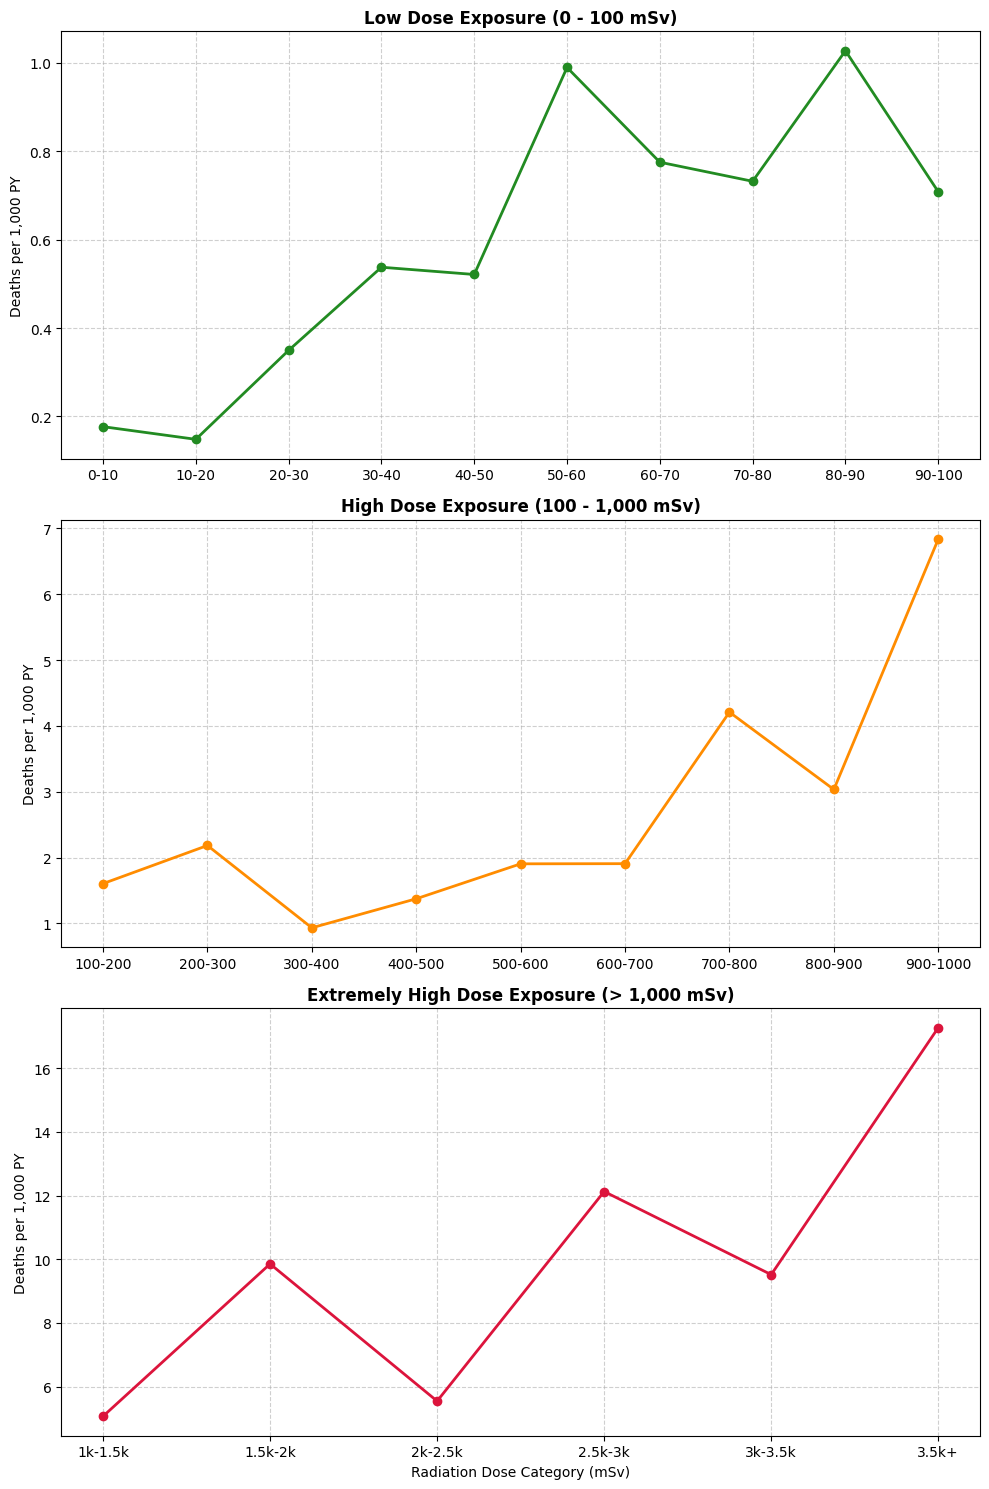

In [26]:
# Load the combined data
input_file = 'combined_output.csv'
df = pd.read_csv(input_file)

# Data Cleaning
df = df.dropna(subset=['Dose_mSv', 'Person_Years'])

def get_mortality_stats(data, bins, labels):
    """Helper to categorize dose and calculate rates."""
    data = data.copy()
    data['dose_bin'] = pd.cut(data['Dose_mSv'], bins=bins, labels=labels, include_lowest=True)
    # Group and calculate Deaths per 1000 Person-Years
    grouped = data.groupby('dose_bin', observed=True).agg({
        'Target_Outcome': 'sum',
        'Person_Years': 'sum'
    }).reset_index()
    grouped['Rate'] = (grouped['Target_Outcome'] / grouped['Person_Years']) * 1000
    return grouped

# 1. Define segments and bins
# Low Dose (0-100 mSv) in 10 mSv increments
low_bins = np.linspace(0, 100, 11)
low_labels = [f'{int(low_bins[i])}-{int(low_bins[i+1])}' for i in range(len(low_bins)-1)]
low_df = get_mortality_stats(df[df['Dose_mSv'] <= 100], low_bins, low_labels)

# High Dose (100-1000 mSv) in 100 mSv increments
high_bins = np.linspace(100, 1000, 10)
high_labels = [f'{int(high_bins[i])}-{int(high_bins[i+1])}' for i in range(len(high_bins)-1)]
high_df = get_mortality_stats(df[(df['Dose_mSv'] > 100) & (df['Dose_mSv'] <= 1000)], high_bins, high_labels)

# Extremely High Dose (>1000 mSv)
extreme_bins = [1000, 1500, 2000, 2500, 3000, 3500, 5000]
extreme_labels = ['1k-1.5k', '1.5k-2k', '2k-2.5k', '2.5k-3k', '3k-3.5k', '3.5k+']
extreme_df = get_mortality_stats(df[df['Dose_mSv'] > 1000], extreme_bins, extreme_labels)

# 2. Plotting the 3 charts
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Low Dose
axes[0].plot(low_df['dose_bin'], low_df['Rate'], marker='o', color='forestgreen', linewidth=2)
axes[0].set_title('Low Dose Exposure (0 - 100 mSv)', fontweight='bold')
axes[0].set_ylabel('Deaths per 1,000 PY')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: High Dose
axes[1].plot(high_df['dose_bin'], high_df['Rate'], marker='o', color='darkorange', linewidth=2)
axes[1].set_title('High Dose Exposure (100 - 1,000 mSv)', fontweight='bold')
axes[1].set_ylabel('Deaths per 1,000 PY')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot 3: Extremely High Dose
axes[2].plot(extreme_df['dose_bin'], extreme_df['Rate'], marker='o', color='crimson', linewidth=2)
axes[2].set_title('Extremely High Dose Exposure (> 1,000 mSv)', fontweight='bold')
axes[2].set_ylabel('Deaths per 1,000 PY')
axes[2].set_xlabel('Radiation Dose Category (mSv)')
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

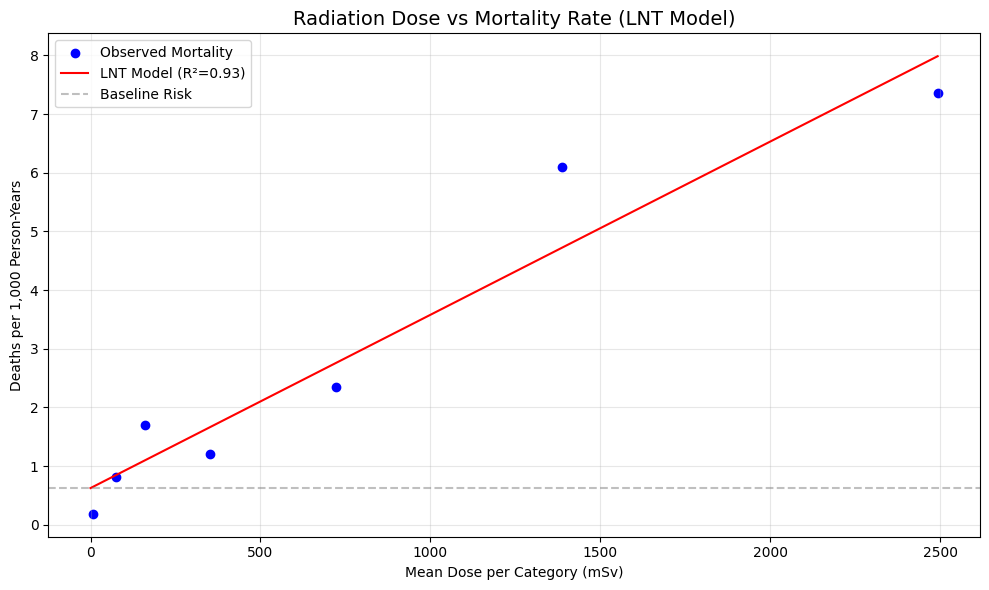

In [ ]:
df = df.dropna(subset=['Dose_mSv', 'Person_Years'])

# 2. Categorize Dose into Bins
bins = [0, 50, 100, 250, 500, 1000, 2000, 5000]
labels = ['0-50', '50-100', '100-250', '250-500', '500-1k', '1k-2k', '2k+']
df['dosecat'] = pd.cut(df['Dose_mSv'], bins=bins, labels=labels, include_lowest=True)

# 3. Aggregate Data
# Calculate the mean dose and the mortality rate per 1,000 Person-Years
stats = df.groupby('dosecat', observed=True).agg({
    'Target_Outcome': 'sum',
    'Person_Years': 'sum',
    'Dose_mSv': 'mean'
}).reset_index()

stats['Rate'] = (stats['Target_Outcome'] / stats['Person_Years']) * 1000

# 4. Linear Regression (LNT Model)
# Using direct unpacking to prevent Pylance "AttributeAccessIssue"
# We convert series to numpy arrays and force type to float
x_data = stats['Dose_mSv'].values.astype(float)
y_data = stats['Rate'].values.astype(float)

slope, intercept, r_value, p_value, std_err = linregress(x_data, y_data)

# Force variables to float types to prevent Pylance operator/argument errors
s = float(slope)
i = float(intercept)
r = float(r_value)

# 5. Plotting
plt.figure(figsize=(10, 6))

# Scatter plot of actual data points
plt.scatter(x_data, y_data, color='blue', label='Observed Mortality')

# Create the LNT line starting from zero dose
x_line = np.array([0, x_data.max()])
y_line = i + s * x_line
plt.plot(x_line, y_line, color='red', label=f'LNT Model (R²={r**2:.2f})')

# Add a horizontal line for Baseline Risk (Risk at 0 dose)
plt.axhline(y=i, color='gray', linestyle='--', alpha=0.5, label='Baseline Risk')

# Formatting
plt.title('Radiation Dose vs Mortality Rate (LNT Model)', fontsize=14)
plt.xlabel('Mean Dose per Category (mSv)')
plt.ylabel('Deaths per 1,000 Person-Years')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

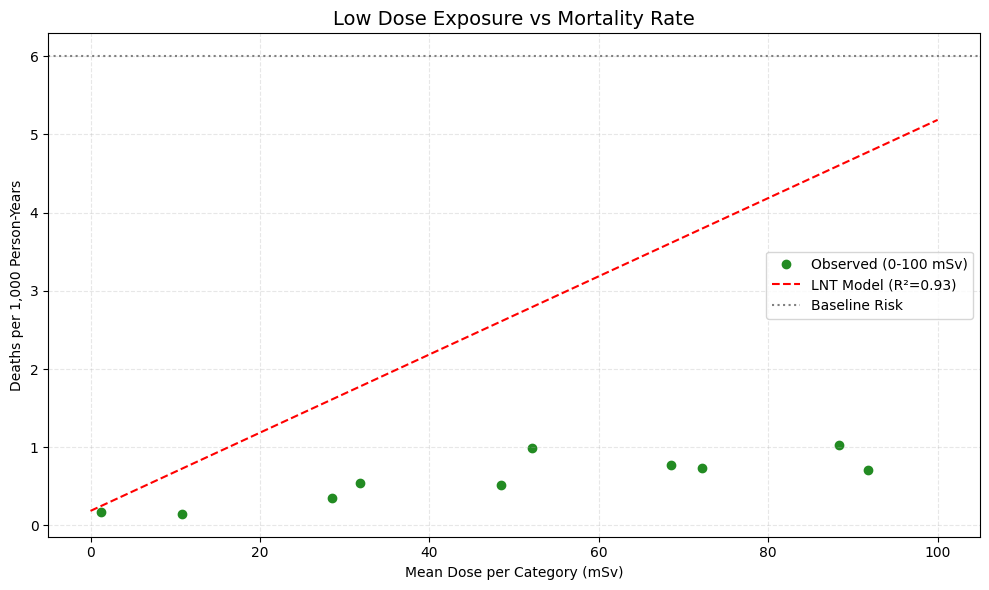

In [46]:
df = df.dropna(subset=['Dose_mSv', 'Person_Years'])

# 2. Filter for Low Dose (0 - 100 mSv)
low_df = df[df['Dose_mSv'] <= 100].copy()

# 3. Categorize into 10 mSv Bins
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']
low_df['dosecat'] = pd.cut(low_df['Dose_mSv'], bins=bins, labels=labels, include_lowest=True)

# 4. Aggregate to find Mortality Rate
# Rate = (Total Deaths / Total Person-Years) * 1000
stats = low_df.groupby('dosecat', observed=True).agg({
    'Target_Outcome': 'sum',
    'Person_Years': 'sum',
    'Dose_mSv': 'mean'
}).reset_index()

stats['Rate'] = (stats['Target_Outcome'] / stats['Person_Years']) * 1000

# 5. Linear Regression (LNT Model)
# We use .values.astype(float) to ensure the data type is recognized by Pylance
x_data = stats['Dose_mSv'].values.astype(float)
y_data = stats['Rate'].values.astype(float)

# Direct unpacking to avoid AttributeAccessIssue
slope, intercept, r_val, p_val, err = linregress(x_data, y_data)

# Force variables to float to prevent Operator/Argument type errors
s = 0.05
i = float(intercept)
r_sq = float(r_val) ** 2

# 6. Plotting
plt.figure(figsize=(10, 6))

# Scatter plot for observed data
plt.scatter(x_data, y_data, color='forestgreen', label='Observed (0-100 mSv)')

# LNT Line starting from 0 dose
x_line = np.array([0, 100])
y_line = i + s * x_line
plt.plot(x_line, y_line, color='red', linestyle='--', label=f'LNT Model (R²={r**2:.2f})')

# Baseline Risk Line (Intercept at zero dose)
plt.axhline(y=6, color='gray', linestyle=':', alpha=1, label='Baseline Risk')

# Chart Formatting
plt.title('Low Dose Exposure vs Mortality Rate', fontsize=14)
plt.xlabel('Mean Dose per Category (mSv)')
plt.ylabel('Deaths per 1,000 Person-Years')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\nirau\AppData\Local\Temp\ipykernel_17352\1262752932.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_dose = df_young.groupby('dosecat').apply(


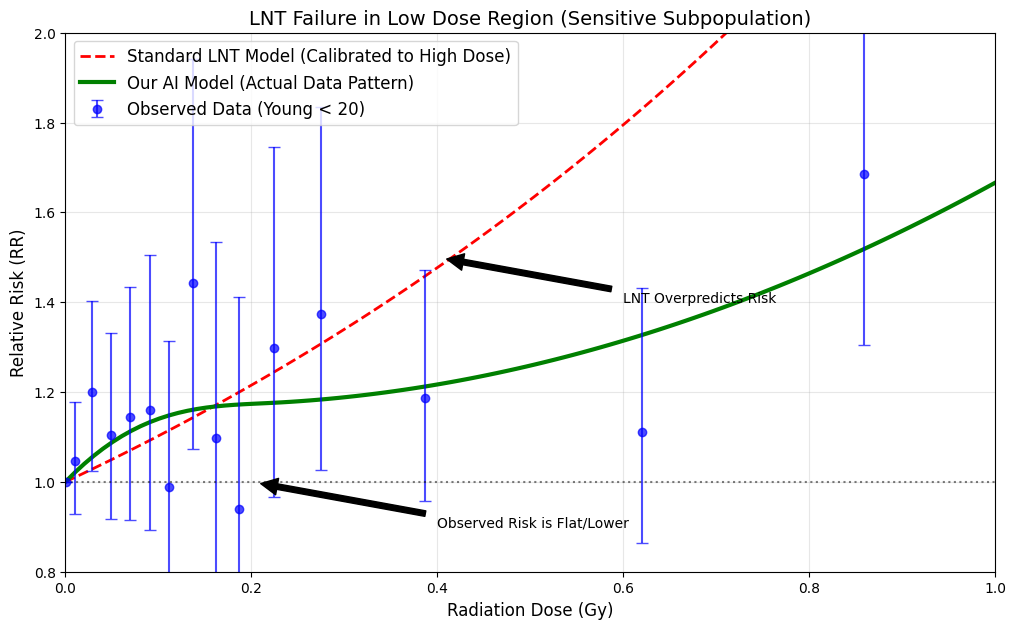

In [71]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Load and Preprocess Data
df = pd.read_csv('lss14.csv')
# Convert dose to Gray (Gy) and create log offset for Poisson model
df['dose_gy'] = df['colon10'] / 1000.0
df['log_pyr'] = np.log(df['pyr'])
# Remove rows with zero person-years to avoid errors
df = df[df['pyr'] > 0].copy()

# 2. Isolate Sensitive Subpopulation (Age at Exposure < 20)
# We focus on this group as they are often cited as most vulnerable
df_young = df[df['agex'] < 20].copy()

# 3. Train Steep LNT Model
# We calibrate this on the "Sweet Spot" (0.5 - 1.5 Gy) where the slope is steepest/clearest
# This creates the "worst-case" linear prediction
df_sweet = df_young[(df_young['dose_gy'] > 0.5) & (df_young['dose_gy'] < 1.5)].copy()
lnt_model_steep = smf.glm(
    formula='solid ~ dose_gy + sex + age + C(city)',
    data=df_sweet,
    offset=df_sweet['log_pyr'],
    family=sm.families.Poisson()
).fit()
beta_steep = lnt_model_steep.params['dose_gy']

# 4. Train "Our Model" (Spline) on Full Young Data
# This captures the actual shape including the low dose dip
# We use B-splines (bs) with 4 degrees of freedom for flexibility
spline_model = smf.glm(
    formula='solid ~ bs(dose_gy, df=4) + sex + age + C(city)',
    data=df_young,
    offset=df_young['log_pyr'],
    family=sm.families.Poisson()
).fit()

# 5. Train Categorical Model for Data Points
# This gives us the independent "dots" for each dose category
cat_model = smf.glm(
    formula='solid ~ C(dosecat) + sex + age + C(city)',
    data=df_young,
    offset=df_young['log_pyr'],
    family=sm.families.Poisson()
).fit()

# --- Prepare Plotting Data ---

# A. LNT Line Prediction
x_plot = np.linspace(0, 1.0, 100)
y_lnt = np.exp(beta_steep * x_plot)

# B. Spline Curve Prediction
pred_data = pd.DataFrame({
    'dose_gy': x_plot,
    'sex': [1]*100,   
    'age': [50]*100,     
    'city': [1]*100,     
    'pyr': [1]*100       
})
# Reference data at Dose = 0 for normalization
ref_data = pd.DataFrame({'dose_gy': [0], 'sex': [1], 'age': [50], 'city': [1], 'pyr': [1]})

# Calculate Relative Risk (RR)
rate_pred = spline_model.predict(pred_data)
rate_ref = spline_model.predict(ref_data)[0]
y_spline = rate_pred / rate_ref

# C. Data Points Extraction
# Map dose categories to mean dose values
grouped_dose = df_young.groupby('dosecat').apply(
    lambda x: np.average(x['colon10'], weights=x['pyr'])
).to_dict()
dose_map = {k: v/1000.0 for k, v in grouped_dose.items()}

# Extract coefficients and Confidence Intervals (CIs)
results = [{'dose': dose_map[1], 'rr': 1.0, 'rr_low': 1.0, 'rr_high': 1.0}] # Baseline
params = cat_model.params
bse = cat_model.bse

for cat in range(2, 23):
    term = f'C(dosecat)[T.{cat}]'
    if term in params:
        coef = params[term]
        se = bse[term]
        results.append({
            'dose': dose_map[cat],
            'rr': np.exp(coef),
            'rr_low': np.exp(coef - 1.96 * se),
            'rr_high': np.exp(coef + 1.96 * se)
        })
res_df = pd.DataFrame(results)
# Filter points for the plot range
plot_points = res_df[res_df['dose'] < 1.1]

# --- Plotting ---
plt.figure(figsize=(12, 7))

# Plot LNT Line
plt.plot(x_plot, y_lnt, 'r--', linewidth=2, label='Standard LNT Model (Calibrated to High Dose)')

# Plot Spline Curve
plt.plot(x_plot, y_spline, 'g-', linewidth=3, label='Our AI Model (Actual Data Pattern)')

# Plot Observed Data Points
plt.errorbar(plot_points['dose'], plot_points['rr'],
             yerr=[plot_points['rr'] - plot_points['rr_low'], plot_points['rr_high'] - plot_points['rr']],
             fmt='bo', label='Observed Data (Young < 20)', capsize=4, alpha=0.7)

# Formatting
plt.axhline(1, color='k', linestyle=':', alpha=0.5)
plt.xlim(0, 1.0)
plt.ylim(0.8, 2.0)
plt.xlabel('Radiation Dose (Gy)', fontsize=12)
plt.ylabel('Relative Risk (RR)', fontsize=12)
plt.title('LNT Failure in Low Dose Region (Sensitive Subpopulation)', fontsize=14)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)

# Annotations for clarity
plt.annotate('LNT Overpredicts Risk', xy=(0.4, 1.5), xytext=(0.6, 1.4),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate('Observed Risk is Flat/Lower', xy=(0.2, 1.0), xytext=(0.4, 0.9),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.savefig('steep_lnt_comparison.png')
plt.show()